### Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries for model training and plotting
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv3D, MaxPooling3D, BatchNormalization, Concatenate, GlobalAveragePooling3D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tqdm import tqdm

In [ ]:
# Define the fusion model
def create_fusion_3d_cnn(input_shape_flow, input_shape_temporal):
    input_flow = Input(shape=input_shape_flow)
    input_temporal = Input(shape=input_shape_temporal)

    # First branch: Processing Optical Flow data
    x_flow = Conv3D(16, kernel_size=(3, 3, 3), activation='relu', kernel_regularizer=l2(0.001))(input_flow)
    x_flow = MaxPooling3D(pool_size=(2, 2, 2))(x_flow)
    x_flow = BatchNormalization(momentum=0.99)(x_flow)

    # Second branch: Processing Temporal Frames data
    x_temporal = Conv3D(16, kernel_size=(3, 3, 3), activation='relu', kernel_regularizer=l2(0.001))(input_temporal)
    x_temporal = MaxPooling3D(pool_size=(2, 2, 2))(x_temporal)
    x_temporal = BatchNormalization(momentum=0.99)(x_temporal)

    # Align the shapes of both branches using Conv3D to ensure compatibility for concatenation
    x_flow_resized = Conv3D(32, kernel_size=(1, 1, 1), activation='relu')(x_flow)
    x_temporal_resized = Conv3D(32, kernel_size=(1, 1, 1), activation='relu')(x_temporal)

    # Concatenate both modalities after resizing the feature maps
    x = Concatenate()([x_flow_resized, x_temporal_resized])

    # Further processing
    x = Conv3D(64, kernel_size=(3, 3, 3), activation='relu', kernel_regularizer=l2(0.001))(x)
    x = MaxPooling3D(pool_size=(2, 2, 2))(x)
    x = BatchNormalization(momentum=0.99)(x)

    # Global Average Pooling
    x = GlobalAveragePooling3D()(x)

    # Fully Connected Layers
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.5)(x)

    # Output layer for binary classification (Violent/NonViolent)
    output_layer = Dense(2, activation='softmax')(x)

    # Create and return the model
    model = Model(inputs=[input_flow, input_temporal], outputs=output_layer)
    return model

# Input shapes (set according to your data)
input_shape_flow = (16, 60, 90, 2)  # Optical Flow input
input_shape_temporal = (16, 60, 90, 3)  # Temporal Frames input (RGB)

# Create the fusion model
fusion_model = create_fusion_3d_cnn(input_shape_flow, input_shape_temporal)

# Compile the model with gradient clipping and reduced learning rate
optimizer = Adam(learning_rate=0.0001, clipvalue=1.0)
fusion_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
fusion_model.summary()



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 16, 60, 90, 2)  │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, 16, 60, 90, 3)  │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d (Conv3D)           │ (None, 14, 58, 88, 16) │            880 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_1 (Conv3D)         │ (None, 14, 58, 88, 16) │          1,312 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling3d             │ (None, 7, 29, 44, 16)  │              0 │ conv3d[0][0]           │
│ (MaxPooling3D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling3d_1           │ (None, 7, 29, 44, 16)  │              0 │ conv3d_1[0][0]         │
│ (MaxPooling3D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 7, 29, 44, 16)  │             64 │ max_pooling3d[0][0]    │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 7, 29, 44, 16)  │             64 │ max_pooling3d_1[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_2 (Conv3D)         │ (None, 7, 29, 44, 32)  │            544 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_3 (Conv3D)         │ (None, 7, 29, 44, 32)  │            544 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 7, 29, 44, 64)  │              0 │ conv3d_2[0][0],        │
│                           │                        │                │ conv3d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv3d_4 (Conv3D)         │ (None, 5, 27, 42, 64)  │        110,656 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling3d_2           │ (None, 2, 13, 21, 64)  │              0 │ conv3d_4[0][0]         │
│ (MaxPooling3D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 2, 13, 21, 64)  │            256 │ max_pooling3d_2[0][0]  │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling3d  │ (None, 64)             │              0 │ batch_normalization_2… │
│ (GlobalAveragePooling3D)  │                        │                │                        │
├──────────────────────

 Total params: 131,026 (511.82 KB)

 Trainable params: 130,834 (511.07 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# Function to load video frames from a folder
def load_frames_from_folder(folder_path, input_shape, file_prefix, channels=3):
    frames = []
    video_count = 0  # Counter for the number of videos

    # Iterate through each video folder with a progress bar
    for video_folder in tqdm(os.listdir(folder_path), desc="Loading videos"):
        video_path = os.path.join(folder_path, video_folder)
        video_frames = []

        if not os.path.isdir(video_path):
            print(f"Skipping non-folder: {video_path}")
            continue

        video_count += 1  # Increment video count

        # Sort files with the specific prefix and handle irregular names
        frame_files = sorted(
            [f for f in os.listdir(video_path) if f.startswith(file_prefix) and f.endswith('.jpg')],
            key=lambda x: int(''.join(filter(str.isdigit, x.split('_')[-1])))  # Extract numeric part robustly
        )

        for frame_file in frame_files:
            frame_path = os.path.join(video_path, frame_file)
            frame = cv2.imread(frame_path, cv2.IMREAD_GRAYSCALE if channels == 2 else cv2.IMREAD_COLOR)
            if frame is not None:
                # Resize the frame to match the input shape
                frame = cv2.resize(frame, (input_shape[2], input_shape[1]))

                # If optical flow (2 channels), stack the same frame for the second channel
                if channels == 2:
                    frame = np.stack([frame, frame], axis=-1)  # Create a 2-channel frame

                video_frames.append(frame)
            else:
                print(f"Frame {frame_path} could not be loaded.")

        # Ensure the number of frames matches the required length (truncate or pad)
        if len(video_frames) > input_shape[0]:
            video_frames = video_frames[:input_shape[0]]  # Truncate
        elif len(video_frames) < input_shape[0]:
            # Pad with the last frame if not enough frames
            last_frame = video_frames[-1] if video_frames else np.zeros((input_shape[1], input_shape[2], input_shape[3]))
            while len(video_frames) < input_shape[0]:
                video_frames.append(last_frame)

        frames.append(np.array(video_frames))

    print(f"Total videos loaded: {video_count}")  # Display the number of videos loaded
    return np.array(frames)

# Define paths and input shapes
base_path = "/content/drive/MyDrive/movie_frames"
optical_flow_path = os.path.join(base_path, "optical_flow_frames")
temporal_frames_path = os.path.join(base_path, "temporal_frames")

# Update frame count to 100
input_shape_flow = (16, 60, 90, 2)  # Optical flow input shape (2 channels)
input_shape_temporal = (16, 60, 90, 3)  # Temporal frames input shape (3 channels)

# Load optical flow and temporal frames
train_data_flow = load_frames_from_folder(os.path.join(optical_flow_path, "Violent"), input_shape_flow, "flow_", channels=2)
train_data_temporal = load_frames_from_folder(os.path.join(temporal_frames_path, "Violent"), input_shape_temporal, "frame_", channels=3)

test_data_flow = load_frames_from_folder(os.path.join(optical_flow_path, "NonViolent"), input_shape_flow, "flow_", channels=2)
test_data_temporal = load_frames_from_folder(os.path.join(temporal_frames_path, "NonViolent"), input_shape_temporal, "frame_", channels=3)

# Assuming binary classification: Violent -> 1, NonViolent -> 0
train_labels = np.ones((train_data_flow.shape[0], 2))  # 1 for Violent
test_labels = np.zeros((test_data_flow.shape[0], 2))  # 0 for NonViolent

# Print shapes of the data
print(f"Train Flow Data Shape: {train_data_flow.shape}")
print(f"Train Temporal Data Shape: {train_data_temporal.shape}")
print(f"Test Flow Data Shape: {test_data_flow.shape}")
print(f"Test Temporal Data Shape: {test_data_temporal.shape}")


Loading videos: 100%|██████████| 124/124 [25:10<00:00, 12.18s/it]


Total videos loaded: 124


Loading videos: 100%|██████████| 124/124 [13:59<00:00,  6.77s/it]


Total videos loaded: 124


Loading videos: 100%|██████████| 123/123 [56:33<00:00, 27.59s/it]


Total videos loaded: 123


Loading videos: 100%|██████████| 123/123 [30:22<00:00, 14.82s/it]

Total videos loaded: 123
Train Flow Data Shape: (124, 16, 60, 90, 2)
Train Temporal Data Shape: (124, 16, 60, 90, 3)
Test Flow Data Shape: (123, 16, 60, 90, 2)
Test Temporal Data Shape: (123, 16, 60, 90, 3)


In [ ]:
# Define the optimizer
optimizer = Adam(learning_rate=0.0001, clipvalue=1.0)

# Compile the model
fusion_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # Metric to monitor (e.g., validation loss)
    factor=0.5,               # Factor by which the learning rate will be reduced
    patience=5,               # Number of epochs with no improvement before reducing
    min_lr=1e-6,              # Minimum learning rate
    verbose=1                 # Verbose output (print when learning rate changes)
)

# Train the model and capture history
history = fusion_model.fit(
    [train_data_flow, train_data_temporal],  # Inputs: optical flow and temporal frames
    train_labels,                           # Labels
    epochs=100,                              # Number of epochs
    batch_size=8,                           # Batch size
    validation_data=([test_data_flow, test_data_temporal], test_labels),  # Validation data
    callbacks=[reduce_lr]                   # Add ReduceLROnPlateau callback
)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 23s 716ms/step - accuracy: 0.6757 - loss: 1.8092 - val_accuracy: 0.0000e+00 - val_loss: 0.2416 - learning_rate: 1.0000e-04
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5107 - loss: 1.7675 - val_accuracy: 0.0000e+00 - val_loss: 0.2414 - learning_rate: 1.0000e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6165 - loss: 1.8085 - val_accuracy: 0.0000e+00 - val_loss: 0.2413 - learning_rate: 1.0000e-04
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.5472 - loss: 1.8106 - val_accuracy: 0.0000e+00 - val_loss: 0.2413 - learning_rate: 1.0000e-04
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6015 - loss: 1.8917 - val_accuracy: 0.0000e+00 - val_loss: 0.2414 - learning_rate: 1.0000e-04
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4653 - loss: 1.8586 - val_accuracy: 0.0000e+00 - val_loss: 0.2414 - learning_rate: 1.0000e-04
Epoch 7/100
15/16 ━━━━━━━━━━━━━━━━━━━━

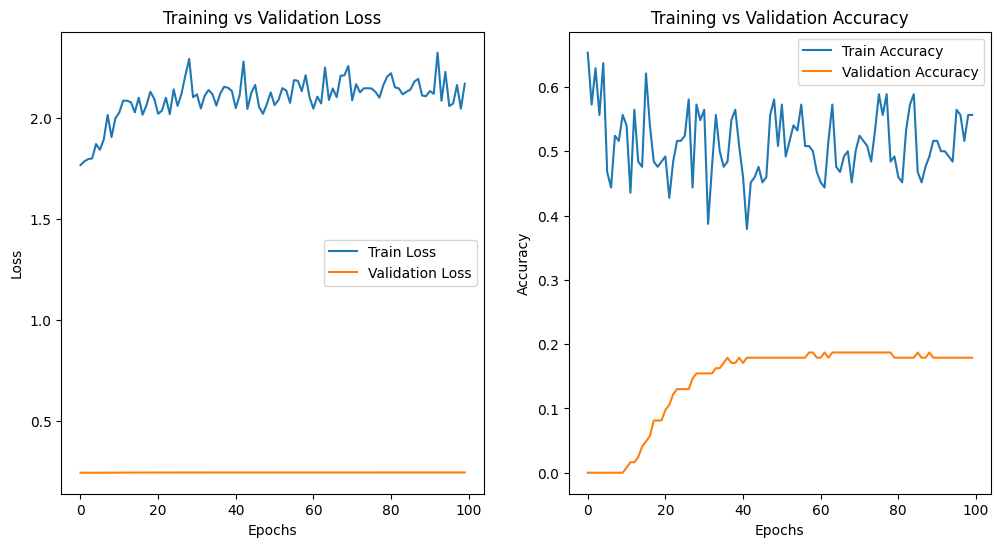

In [ ]:
# Plot Training & Validation Loss
plt.figure(figsize=(12, 6))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
